# DSCI 303 - Project 4

### Sean Graham

**Due: Sunday, June 28, 2020, 11:59 pm**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## Part 1: Loading the Dataset; Preliminary Analysis
This section will involve loadind the data into a DataFrame, and exploring the structure of the data set.

In [5]:
fc = pd.read_csv('forest_cover.txt', sep='\t')
fc.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,Rawah,29,5
1,2590,56,2,212,-6,390,220,235,151,6225,Rawah,29,5
2,2804,139,9,268,65,3180,234,238,135,6121,Rawah,12,2
3,2785,155,18,242,118,3090,238,238,122,6211,Rawah,30,2
4,2595,45,2,153,-1,391,220,234,150,6172,Rawah,29,5


The next cell will determine the size of the dataset, providing the number of rows and columns. When multiplied, these two values will give the number of values in the data frame.

In [6]:
fc.shape

(15120, 13)

The next cell will inspect the distribution of cover types in the datasets.

In [7]:
fc['Cover_Type'].value_counts().sort_index()

,count
Cover_Type,
1,2160
2,2160
3,2160
4,2160
5,2160
6,2160
7,2160


The next cell will create a list of seven colors to be used as a palette in plots that will be created later.

In [8]:
palette = ['orchid', 'lightcoral', 'orange', 'gold', 'lightgreen', 'deepskyblue', 'cornflowerblue']

## Part 2: Distribution of Cover Type by Wilderness Area
This section will involve exploring the relationship between cover type and wilderness area. It will start by determining the distribution of the wilderness areas within the dataset.

In [9]:
fc['Wilderness_Area'].value_counts().sort_index()

,count
Wilderness_Area,
Cache la Poudre,4675
Comanche Peak,6349
Neota,499
Rawah,3597


The next cell will create a DataFrame to determine the how many regions of each cover type are in each of the four wilderness areas.

In [10]:
ct_by_wa = pd.crosstab(fc['Cover_Type'], fc['Wilderness_Area'])
ct_by_wa

Wilderness_Area,Cache la Poudre,Comanche Peak,Neota,Rawah
Cover_Type,,,,
1,0,917,181,1062
2,20,940,66,1134
3,1297,863,0,0
4,2160,0,0,0
5,0,1304,0,856
6,1198,962,0,0
7,0,1363,252,545


The next cell will visually represent the information in the DataFrame that was just created in the form of a stacked bar chart.

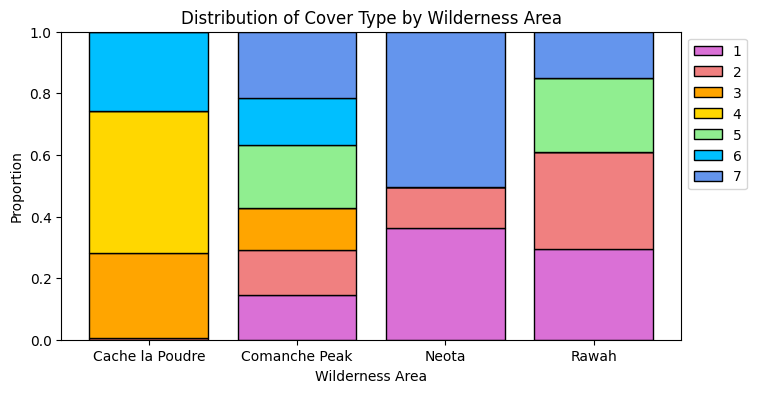

In [11]:
ct_by_wa_props = ct_by_wa / ct_by_wa.sum(axis=0)

bb = np.cumsum(ct_by_wa_props)-ct_by_wa_props

plt.figure(figsize = [8,4])

Wilderness_Area = np.unique(fc.loc[:,'Wilderness_Area'])
Cover_Type = np.unique(fc.loc[:,'Cover_Type'])

for i in range(0, len(Cover_Type)):
    plt.bar(Wilderness_Area, ct_by_wa_props.iloc[i,:], label = Cover_Type[i], bottom = bb.iloc[i,:],
    color = palette[i], edgecolor='black')


plt.xlabel('Wilderness Area')
plt.ylabel('Proportion')
plt.title('Distribution of Cover Type by Wilderness Area')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

## Part 3: Distribution of Cover Type by Soil Type
This section will explore the relationship between cover type and soil type. It will start by creating a DataFrame to determine the number of regions of each cover type there are for each of the 40 soil types.

In [12]:
ct_by_st = pd.crosstab(fc['Cover_Type'], fc['Soil_Type'])
ct_by_st

Soil_Type,1,2,3,4,5,6,8,9,10,11,...,31,32,33,34,35,36,37,38,39,40
Cover_Type,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,5,0,0,0,1,9,5,...,114,230,184,0,3,0,0,80,79,49
2,0,3,12,20,0,7,1,9,81,67,...,97,255,184,12,1,2,0,7,3,3
3,121,283,133,462,55,248,0,0,717,89,...,0,5,0,0,0,0,0,0,0,0
4,139,94,799,133,39,244,0,0,170,24,...,0,0,0,0,0,0,0,0,0,0
5,0,61,0,129,0,0,0,0,64,154,...,87,100,115,4,0,0,0,0,0,0
6,95,182,18,87,71,151,0,0,1101,67,...,7,30,66,2,0,0,0,0,0,0
7,0,0,0,7,0,0,0,0,0,0,...,27,70,67,4,98,8,34,641,575,407


The next cell will visually represent the information in the DataFrame that was just created in the form of a stacked bar chart.

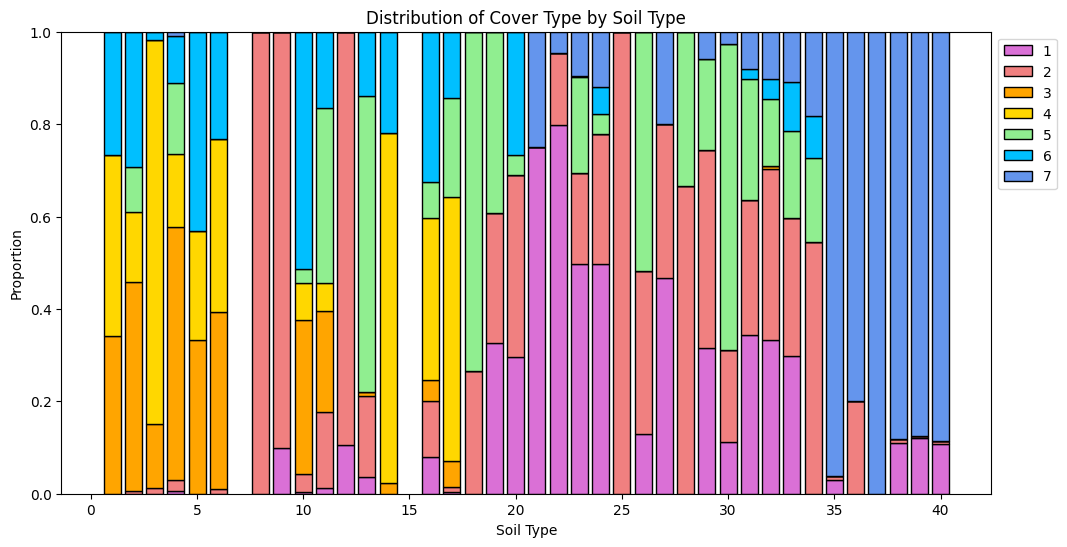

In [13]:
ct_by_st_props = ct_by_st / ct_by_st.sum(axis=0)

bb = np.cumsum(ct_by_st_props)-ct_by_st_props

plt.figure(figsize = [12,6])

Soil_Type = np.unique(fc.loc[:,'Soil_Type'])
Cover_Type = np.unique(fc.loc[:,'Cover_Type'])

for i in range(0, len(Cover_Type)):
    plt.bar(Soil_Type, ct_by_st_props.iloc[i,:], label = Cover_Type[i], bottom = bb.iloc[i,:],
    color = palette[i], edgecolor='black')

plt.xlabel('Soil Type')
plt.ylabel('Proportion')
plt.title('Distribution of Cover Type by Soil Type')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

## Part 4: Distribution of Elevation by Cover Type
This section will explore the relationship between cover type and elevation. It will start by calculating the average elevation for each of the seven cover types.

In [14]:
df = pd.DataFrame(fc.loc[:,['Elevation','Cover_Type']].groupby('Cover_Type').mean())
df

,Elevation
Cover_Type,
1,3128.025926
2,2922.540278
3,2398.423148
4,2223.420370
5,2786.801389
6,2423.276852
7,3362.769907


The next cell will create histograms to visually explore the distribution of elevations for each of the seven cover types.

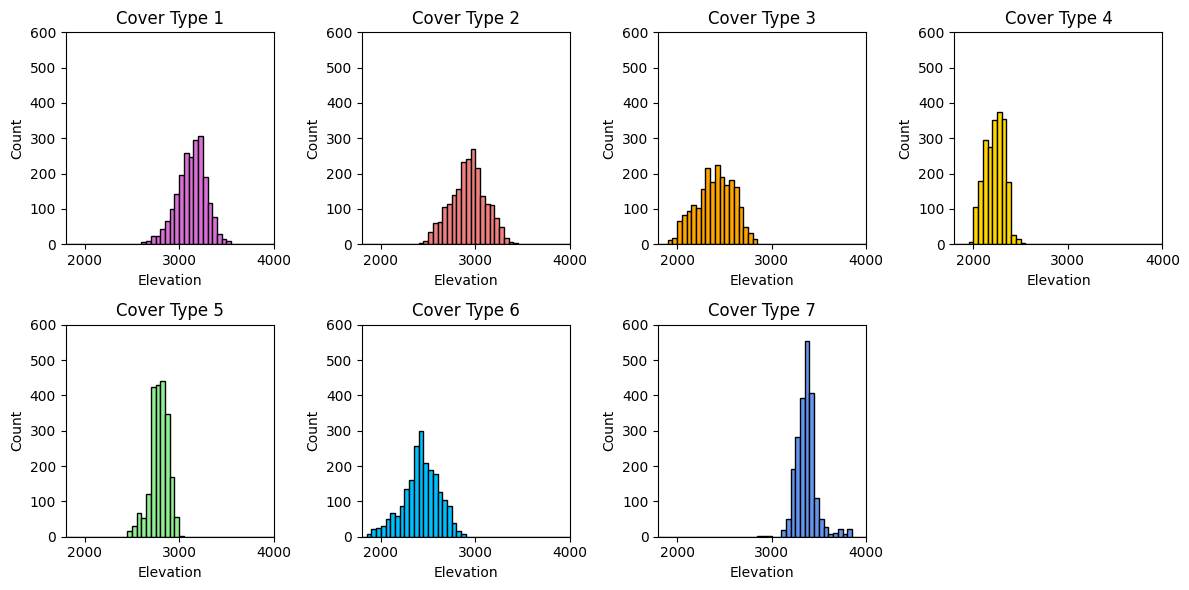

In [15]:
plt.figure(figsize=[12,6])

Cover = fc['Cover_Type']
Elevation = fc['Elevation']

for i in range(0, len(Cover_Type)):
    plt.subplot(2,4,i+1)
    sel = (Cover == Cover_Type[i])
    plt.hist(Elevation[sel], edgecolor = 'black', color = palette[i], bins=np.arange(1800, 4050, 50))

    plt.xlim([1800,4000])
    plt.ylim([0,600])
    plt.xlabel('Elevation')
    plt.ylabel('Count')
    plt.title('Cover Type ' + str(Cover_Type[i]))

plt.tight_layout()
plt.show()

## Part 5: Creating Training, Validation, and Test Sets
This section will invovle encoding our categorical variables and will create training, validation, and test sets. It will start by separating the categorical features, the numerical features, and the labels.

In [ ]:
X_num = fc.iloc[:,0:10].values
X_cat = fc.iloc[:,10:12].values
y = fc.iloc[:,12].values

print('Numerical Feature Array Shape:   ' + str(X_num.shape))
print('Categorical Feature Array Shape: ' + str(X_cat.shape))
print('Label Array Shape:               ' + str(y.shape))

Numerical Feature Array Shape:   (15120, 10)
Categorical Feature Array Shape: (15120, 2)
Label Array Shape:               (15120,)


The next cell will encode the categorical variables using one-hot encoding.

In [ ]:
encoder = OneHotEncoder(sparse = False)
encoder.fit(X_cat)
X_enc = encoder.transform(X_cat)
print('Encoded Feature Array Shape: ' + str(X_enc.shape))

Encoded Feature Array Shape: (15120, 42)


The next cell will combine the numerical features with the encoded features.

In [ ]:
X = np.hstack([X_num, X_enc])
print('Feature Array Shape: ' + str(X.shape))

Feature Array Shape: (15120, 52)


The next cell will split the data into training, validation, and test sets, using a 70/15/15 split.

In [ ]:
X_train, X_hold, y_train, y_hold =\
    train_test_split(X, y, test_size = 0.3, random_state=1, stratify = y)
X_valid, X_test, y_valid, y_test =\
train_test_split(X_hold, y_hold, test_size = 0.5, random_state=1, stratify = y_hold)

print('Training Features Shape:   ' + str(X_train.shape))
print('Validation Features Shape: ' + str(X_valid.shape))
print('Test Features Shape:       ' + str(X_test.shape))

Training Features Shape:   (10584, 52)
Validation Features Shape: (2268, 52)
Test Features Shape:       (2268, 52)


## Part 6: Logistic Regression Model
This section will involve creating and evaluating a logistic regression model.

In [ ]:
lr_mod = LogisticRegression(solver='lbfgs', max_iter = 1000, multi_class = 'multinomial', penalty='none')
lr_mod.fit(X_train, y_train)

train_acc = lr_mod.score(X_train, y_train)
valid_acc = lr_mod.score(X_valid, y_valid)

print('Training Accuracy:  ', round(train_acc, 4))
print('Validation Accuracy:', round(valid_acc, 4))

Training Accuracy:   0.6139
Validation Accuracy: 0.6177


/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:947: ConvergenceWarning: lbfgs failed to converge. Increase the number of iterations.
  "of iterations.", ConvergenceWarning)


## Part 7: Decision Tree Models
This section will involve creating and evaluating several decision tree models.

In [ ]:
dt_train_acc = []
dt_valid_acc = []

depth_range = range(2,31)

for d in depth_range:
    np.random.seed(1)
    temp_tree = DecisionTreeClassifier(max_depth = d)
    temp_tree.fit(X_train, y_train)
    dt_train_acc.append(temp_tree.score(X_train, y_train))
    dt_valid_acc.append(temp_tree.score(X_valid, y_valid))

dt_idx = np.argmax(dt_valid_acc)
dt_opt_depth = depth_range[dt_idx]

train_acc = dt_train_acc[dt_idx]
valid_acc = dt_valid_acc[dt_idx]

print('Optimal Value for max_depth:          ', round(dt_opt_depth, 4))
print('Training Accuracy for Optimal Model:  ', round(train_acc, 4))
print('Validation Accuracy for Optimal Model:', round(valid_acc, 4))

Optimal Value for max_depth:           18
Training Accuracy for Optimal Model:   0.9804
Validation Accuracy for Optimal Model: 0.772


The next cell will plot the training and validation curves as a function of max_depth.

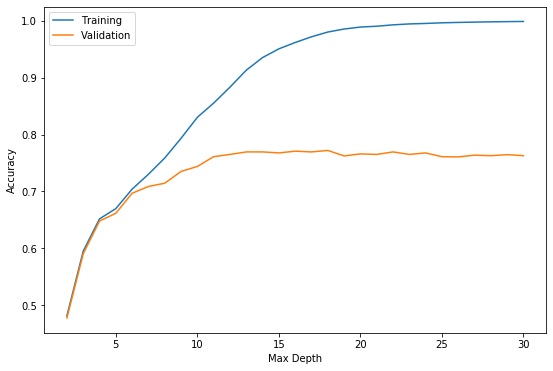

In [ ]:
plt.figure(figsize=([9, 6]))
plt.plot(depth_range, dt_train_acc, label = 'Training')
plt.plot(depth_range, dt_valid_acc, label = 'Validation')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Part 8: Random Forest Models
This section will involve creating and evaluating several random forest models.

In [ ]:
rf_train_acc = []
rf_valid_acc = []

depth_range = range(2,31)

for d in depth_range:
    np.random.seed(1)
    temp_forest = RandomForestClassifier(max_depth = d, n_estimators = 100)
    temp_forest.fit(X_train, y_train)
    rf_train_acc.append(temp_forest.score(X_train, y_train))
    rf_valid_acc.append(temp_forest.score(X_valid, y_valid))

rf_idx = np.argmax(rf_valid_acc)
rf_opt_depth = depth_range[rf_idx]

train_acc = rf_train_acc[rf_idx]
valid_acc = rf_valid_acc[rf_idx]

print('Optimal Value for max_depth:          ', round(rf_opt_depth, 4))
print('Training Accuracy for Optimal Model:  ', round(train_acc, 4))
print('Validation Accuracy for Optimal Model:', round(valid_acc, 4))

Optimal Value for max_depth:           28
Training Accuracy for Optimal Model:   1.0
Validation Accuracy for Optimal Model: 0.8677


The next cell will plot the training and validation curves as a function of max_depth.

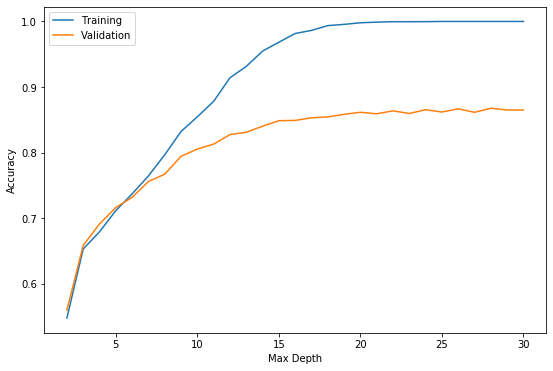

In [ ]:
plt.figure(figsize=([9, 6]))
plt.plot(depth_range, rf_train_acc, label = 'Training')
plt.plot(depth_range, rf_valid_acc, label = 'Validation')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Part 9: Create and Evaluate Final Model
This section will use the random forest model as the final model, as it has the highest validation accuracy. The parameters will be d = 28 and n_estimators = 100

In [ ]:
np.random.seed(1)
final_model = RandomForestClassifier(max_depth = 28, n_estimators = 100)
final_model.fit(X_train, y_train)

final_train_acc = final_model.score(X_train, y_train)
fianl_valid_acc = final_model.score(X_valid, y_valid)
final_test_acc = final_model.score(X_test, y_test)

print('Training Accuracy:  ', round(final_train_acc, 4))
print('Validation Accuracy:', round(fianl_valid_acc, 4))
print('Test Accuracy:      ', round(final_test_acc, 4))

Training Accuracy:   1.0
Validation Accuracy: 0.8677
Test Accuracy:       0.8593


The next cell will create and display a confusion matrix detailing the model's performance on the test set.

In [ ]:
test_pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(data = cm, index = range(1,8), columns = range(1,8))
cm_df

,1,2,3,4,5,6,7
1,236,63,2,0,5,0,18
2,53,239,6,0,13,10,3
3,0,2,262,18,2,40,0
4,0,0,6,313,0,5,0
5,0,11,4,0,305,4,0
6,0,0,33,11,1,279,0
7,8,1,0,0,0,0,315


The next cell will generate a classification report to provide further insight into the model's performance on the test set.

In [ ]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           1       0.79      0.73      0.76       324
           2       0.76      0.74      0.75       324
           3       0.84      0.81      0.82       324
           4       0.92      0.97      0.94       324
           5       0.94      0.94      0.94       324
           6       0.83      0.86      0.84       324
           7       0.94      0.97      0.95       324

    accuracy                           0.86      2268
   macro avg       0.86      0.86      0.86      2268
weighted avg       0.86      0.86      0.86      2268

